# SAFERec: Self-Attention and Frequency Enriched Model for Next Basket Recommendation

Paper: https://arxiv.org/pdf/2412.14302

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import os

import numpy as np
import pandas as pd

os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
# os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'

device = 'cpu'
print(f"Using device: {device}")

torch.set_num_threads(1)
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

print(f"Torch threads: {torch.get_num_threads()}")


import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)

from tecd_retail_recsys.data import DataPreprocessor
from tecd_retail_recsys.metrics import calculate_metrics

Using device: cpu
Torch threads: 1


In [3]:
dp = DataPreprocessor(
    day_begin=1082, 
    day_end=1308, 
    val_days=20, 
    test_days=20, 
    min_user_interactions=1, 
    min_item_interactions=20
)
train_df, val_df, test_df = dp.preprocess()

Starting data preprocessing...
Loading events from t_ecd_small_partial/dataset/small/retail/events
Loaded 236,479,226 total events
Loading items data from t_ecd_small_partial/dataset/small/retail/items.pq
Loaded 250,171 items with features: ['item_id', 'item_brand_id', 'item_category', 'item_subcategory', 'item_price', 'item_embedding']
Merged item features. Data shape: (236479226, 12)
Filtered to 3,758,762 events with action_type='added-to-cart'
After filtering (min_user_interactions=1, min_item_interactions=20): 3,249,972 events, 84,944 users, 30,954 items
Created mappings: 84944 users, 30954 items
Temporal split - Train: days < 1269 (902,543 events), Val: days 1269-1288 (228,339 events), Test: days >= 1289 (223,395 events)
Users in each part (train, val, test) - 7425


In [4]:
def group_by_baskets(df, time_window_hours=2, min_basket_size=2):
    """
    Group interactions into baskets by user using time windows.
    """
    if not pd.api.types.is_datetime64_any_dtype(df['timestamp']):
        df = df.copy()
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
    
    df = df.sort_values(['user_id', 'timestamp']).reset_index(drop=True)
    
    user_baskets = {}
    
    for user_id, group in df.groupby('user_id'):
        group = group.sort_values('timestamp')
        timestamps = group['timestamp'].values
        items = group['item_id'].values
        
        time_delta = pd.to_timedelta(time_window_hours, unit='h')
        
        baskets = []
        current_basket = [items[0]]
        
        for i in range(1, len(items)):
            gap = pd.Timestamp(timestamps[i]) - pd.Timestamp(timestamps[i - 1])
            if gap <= time_delta:
                current_basket.append(items[i])
            else:
                if len(current_basket) >= min_basket_size:
                    seen = set()
                    deduped = []
                    for item in current_basket:
                        if item not in seen:
                            seen.add(item)
                            deduped.append(item)
                    baskets.append(deduped)
                current_basket = [items[i]]

        if len(current_basket) >= min_basket_size:
            seen = set()
            deduped = []
            for item in current_basket:
                if item not in seen:
                    seen.add(item)
                    deduped.append(item)
            baskets.append(deduped)
        
        if baskets:
            user_baskets[user_id] = baskets
    
    user_ids = list(user_baskets.keys())
    return user_baskets, user_ids


train_user_baskets, train_user_ids = group_by_baskets(train_df, time_window_hours=2, min_basket_size=2)
val_user_baskets, val_user_ids = group_by_baskets(val_df, time_window_hours=2, min_basket_size=2)

basket_sizes = [len(b) for baskets in train_user_baskets.values() for b in baskets]
seq_lengths = [len(baskets) for baskets in train_user_baskets.values()]

print(f"Users:                 {len(train_user_baskets)}")
print(f"Total baskets:         {len(basket_sizes)}")
print(f"Basket size:           median={np.median(basket_sizes):.0f}, "
      f"mean={np.mean(basket_sizes):.1f}, "
      f"max={np.max(basket_sizes)}")
print(f"Baskets per user:      median={np.median(seq_lengths):.0f}, "
      f"mean={np.mean(seq_lengths):.1f}, "
      f"max={np.max(seq_lengths)}")
print(f"Users with ≥2 baskets: {sum(1 for s in seq_lengths if s >= 2)} "
      f"({sum(1 for s in seq_lengths if s >= 2)/len(seq_lengths)*100:.0f}%)")


Users:                 7165
Total baskets:         119369
Basket size:           median=4, mean=6.4, max=117
Baskets per user:      median=11, mean=16.7, max=258
Users with ≥2 baskets: 6677 (93%)


In [261]:
from tecd_retail_recsys.models.saferec import SAFERecPipeline, reindex_data

In [262]:
data_reindexed, num_items, old2new, new2old = reindex_data(train_user_baskets)
print(f"Всего уникальных товаров: {num_items}")

Всего уникальных товаров: 30696


In [ ]:
pipe = SAFERecPipeline(
    data=data_reindexed,
    num_items=num_items,

    max_len=50,         # L — макс. число корзин в истории
    d_model=64,         # размерность эмбеддингов
    n_heads=1,          # число голов в Transformer
    n_layers=1,         # число слоёв Transformer
    d_ff=64,            # размерность FFN (None → d_model)
    dropout=0.1,        # dropout rate
    enc_hidden=[64],    # архитектура History Encoder (список скрытых размерностей)

    lr=1e-3,
    weight_decay=0,
    batch_size=64,
    epochs=20,
    patience=5,

    device='mps',
    val_ratio=0.1,      # доля пользователей на валидацию
    seed=42,
)


SAFERecPipeline initialized:
  num_items=30696, max_len=50, d_model=64
  n_heads=1, n_layers=1, dropout=0.1
  train users=6677, val users=616, test users=5545
  device=mps
  total params=5,925,492


In [ ]:
history = pipe.train()

Epoch   1 | lr=0.001000 | loss=0.1484 | val NDCG@100=0.0066 | val Recall@100=0.0082


Epoch   2 | lr=0.001000 | loss=0.0122 | val NDCG@100=0.0321 | val Recall@100=0.0599


Epoch   3 | lr=0.001000 | loss=0.0057 | val NDCG@100=0.0427 | val Recall@100=0.0908


Epoch   4 | lr=0.001000 | loss=0.0037 | val NDCG@100=0.0436 | val Recall@100=0.0925


Epoch   5 | lr=0.001000 | loss=0.0029 | val NDCG@100=0.0441 | val Recall@100=0.0934


...

Epoch  16 | lr=0.001000 | loss=0.0017 | val NDCG@100=0.0897 | val Recall@100=0.1497


Epoch  17 | lr=0.001000 | loss=0.0017 | val NDCG@100=0.0921 | val Recall@100=0.1553


Epoch  18 | lr=0.001000 | loss=0.0016 | val NDCG@100=0.0939 | val Recall@100=0.1570


Epoch  19 | lr=0.001000 | loss=0.0016 | val NDCG@100=0.0940 | val Recall@100=0.1601


Epoch  20 | lr=0.001000 | loss=0.0016 | val NDCG@100=0.0958 | val Recall@100=0.1614
Loaded best model (val NDCG@100=0.0958)


In [ ]:
metrics = pipe.evaluate(on="test")
print(f"\n=== Test Metrics ===")
print(f"NDCG@100:   {metrics['ndcg@100']:.4f}")
print(f"Recall@100: {metrics['recall@100']:.4f}")
print(f"NDCG@10:    {metrics['ndcg@10']:.4f}")
print(f"Recall@10:  {metrics['recall@10']:.4f}")


=== Test Metrics ===
NDCG@100:   0.0966
Recall@100: 0.1630
NDCG@10:    0.0725
Recall@10:  0.0668


In [ ]:
all_users = list(data_reindexed.keys())
recs = pipe.recommend_batch(all_users, top_k=100)

# Обратно в оригинальные item_id
for uid, items in recs.items():
    recs[uid] = [new2old[iid] for iid, score in items]

saferec_recs = pd.DataFrame(recs.items(), columns=["user_id", "saferec_recs"])

In [ ]:
saferec_recs = saferec_recs.merge(joined, on='user_id')

In [268]:
saferec_best_metrics = calculate_metrics(saferec_recs, train_col='train_interactions', model_preds='saferec_recs', gt_col='val_interactions', verbose=True)

[Metrics debug] resolved gt_col='val_interactions' item_id_index=0
[Metrics debug] ratings_true shape: (224118, 3) ratings_pred shape: (716500, 3)
  ratings_true dtypes: {'user_id': dtype('int64'), 'item_id': dtype('int64')}
  ratings_pred dtypes: {'user_id': dtype('int64'), 'item_id': dtype('int64')}
  user_id=11 gt_count=22 pred_count=100 overlap=2
  user_id=14 gt_count=5 pred_count=100 overlap=0
    [ID spaces] gt sample=[9341, 16732, 17585, 28024, 30789] range=[9341, 30789] | rec sample=[368, 1245, 1683, 1809, 2522] range=[368, 30825]
  user_id=21 gt_count=47 pred_count=100 overlap=16

At k=10:
  MAP@10       = 0.3608
  NDCG@10      = 0.6997
  Precision@10 = 0.2676
  Recall@10    = 0.0767

At k=100:
  MAP@100       = 0.1148
  NDCG@100      = 0.3370
  Precision@100 = 0.0760
  Recall@100    = 0.2126

Other Metrics:
  MRR                 = 0.3862
  Catalog Coverage    = 0.4816
  Diversity     = 0.9932  [0=same recs for all, 1=unique recs]
  Novelty             = 0.6793
  Serendipity  

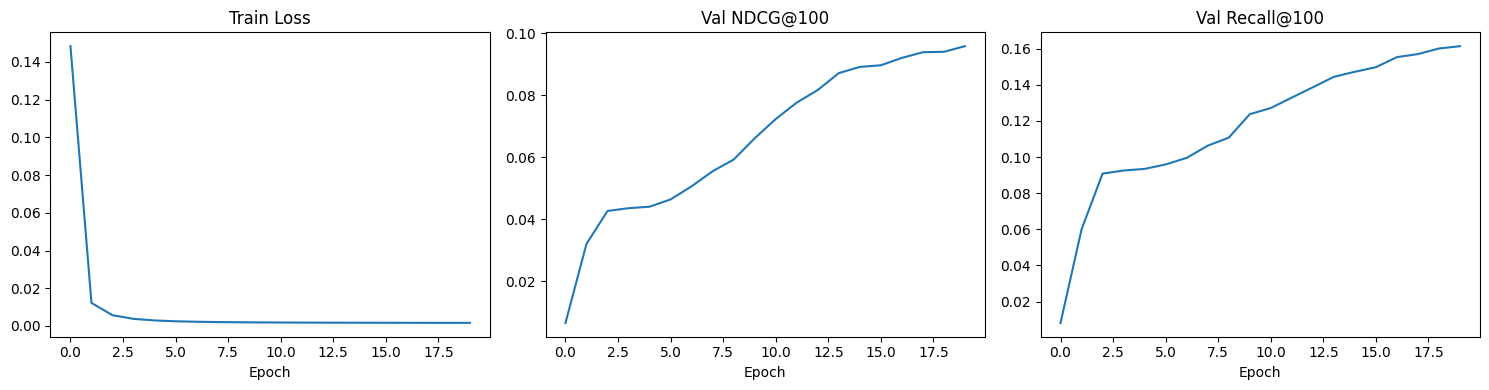

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"])
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")

axes[1].plot(history["val_ndcg100"])
axes[1].set_title("Val NDCG@100")
axes[1].set_xlabel("Epoch")

axes[2].plot(history["val_recall100"])
axes[2].set_title("Val Recall@100")
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

In [ ]:
pipe.save("models/saferec/exp20.pt")

Model saved to models/saferec/exp20.pt


### Инференс лучшей модели

In [ ]:
pipe = SAFERecPipeline(
    data=data_reindexed,
    num_items=num_items,

    max_len=50,         # L — макс. число корзин в истории
    d_model=64,         # размерность эмбеддингов
    n_heads=2,          # число голов в Transformer
    n_layers=2,         # число слоёв Transformer
    d_ff=64,            # размерность FFN (None → d_model)
    dropout=0.1,        # dropout rate
    enc_hidden=[64],    # архитектура History Encoder (список скрытых размерностей)

    lr=1e-3,
    weight_decay=0,
    batch_size=64,
    epochs=20,
    patience=5,

    device='mps',
    val_ratio=0.1,      # доля пользователей на валидацию
    seed=42,
)


pipe.load("models/saferec/exp11.pt")

SAFERecPipeline initialized:
  num_items=30696, max_len=50, d_model=64
  n_heads=2, n_layers=2, dropout=0.1
  train users=6677, val users=616, test users=5545
  device=mps
  total params=5,950,708
Model loaded from models/saferec/exp11.pt


In [274]:
all_users = list(data_reindexed.keys())
recs = pipe.recommend_batch(all_users, top_k=100)

for uid, items in recs.items():
    recs[uid] = [new2old[iid] for iid, score in items]

saferec_recs = pd.DataFrame(recs.items(), columns=["user_id", "saferec_recs"])
saferec_recs = saferec_recs.merge(joined, on='user_id')

saferec_best_metrics = calculate_metrics(saferec_recs, train_col='train_interactions', model_preds='saferec_recs', gt_col='val_interactions', verbose=True)

[Metrics debug] resolved gt_col='val_interactions' item_id_index=0
[Metrics debug] ratings_true shape: (224118, 3) ratings_pred shape: (716500, 3)
  ratings_true dtypes: {'user_id': dtype('int64'), 'item_id': dtype('int64')}
  ratings_pred dtypes: {'user_id': dtype('int64'), 'item_id': dtype('int64')}
  user_id=11 gt_count=22 pred_count=100 overlap=3
  user_id=14 gt_count=5 pred_count=100 overlap=0
    [ID spaces] gt sample=[9341, 16732, 17585, 28024, 30789] range=[9341, 30789] | rec sample=[368, 1683, 1809, 2743, 2811] range=[368, 30825]
  user_id=21 gt_count=47 pred_count=100 overlap=16

At k=10:
  MAP@10       = 0.3608
  NDCG@10      = 0.7003
  Precision@10 = 0.2684
  Recall@10    = 0.0773

At k=100:
  MAP@100       = 0.1149
  NDCG@100      = 0.3375
  Precision@100 = 0.0759
  Recall@100    = 0.2127

Other Metrics:
  MRR                 = 0.3868
  Catalog Coverage    = 0.4681
  Diversity     = 0.9931  [0=same recs for all, 1=unique recs]
  Novelty             = 0.6800
  Serendipity  

In [275]:
from tecd_retail_recsys.utils import get_avg_recs_price, get_item_to_price
item_to_price = get_item_to_price(dp)

avg_saferec_recs_price_val = get_avg_recs_price(saferec_recs, item_to_price, 'saferec_recs')
print(f'Средняя цена рекомендаций модели SAFERec на валидации: {avg_saferec_recs_price_val:.2f}')

Средняя цена рекомендаций модели SAFERec на валидации: -3.82


### **SAFERec: эксперименты**

<table border="1" cellpadding="6" cellspacing="0" style="border-collapse: collapse; text-align: left;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th>#</th>
      <th>Изменение</th>
      <th>Конфигурация</th>
      <th>NDCG@100 val</th>
      <th>Δ vs baseline</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1</td>
      <td>Baseline</td>
      <td>d_model=64, n_heads=2, n_layers=2, d_ff=64, dropout=0.1, max_len=50, enc_hidden=[64], lr=1e-3, BCE loss, epochs=10</td>
      <td>0.2867</td>
      <td>—</td>
    </tr>
    <tr style="background-color: #fff0f0;">
      <td>2</td>
      <td>Динамический pos_weight в BCE</td>
      <td>pw = n_neg / n_pos</td>
      <td>0.2199</td>
      <td style="color:red;">−0.0668</td>
    </tr>
    <tr style="background-color: #f0fff0;">
      <td>3</td>
      <td>Personal frequency score</td>
      <td>+freq_bias_weight * (item_counts / seq_len)</td>
      <td>0.2901</td>
      <td style="color:green;">+0.0034</td>
    </tr>
    <tr style="background-color: #fff0f0;">
      <td>4</td>
      <td>Большая модель</td>
      <td>d_model=128, n_heads=4, n_layers=3, d_ff=256, dropout=0.2, enc_hidden=[256,128], batch=128, wd=1e-5</td>
      <td>0.2289</td>
      <td style="color:red;">−0.0578</td>
    </tr>
    <tr>
      <td>5</td>
      <td>AdamW вместо Adam</td>
      <td>optimizer=AdamW</td>
      <td>0.2871</td>
      <td style="color:green;">+0.0004</td>
    </tr>
    <tr style="background-color: #f0fff0;">
      <td>6</td>
      <td>Нормализация multi-hot по размеру корзины</td>
      <td>basket_multihot = 1 / |basket|, freq_vector бинарный</td>
      <td>0.2846</td>
      <td style="color:red;">−0.0021</td>
    </tr>
    <tr style="background-color: #f0fff0;">
      <td>7</td>
      <td>Больше эпох</td>
      <td>epochs=20</td>
      <td>0.3293</td>
      <td style="color:green;">+0.0426</td>
    </tr>
    <tr style="background-color: #fff0f0;">
      <td>8</td>
      <td>Фиксированный pos_weight=10</td>
      <td>BCE pos_weight=10</td>
      <td>0.3194</td>
      <td style="color:red;">−0.0099</td>
    </tr>
    <tr style="background-color: #f0fff0;">
      <td>9</td>
      <td>Repeat-aware bias</td>
      <td>+repeat_bias * seen_mask</td>
      <td>0.3371</td>
      <td style="color:green;">+0.0078</td>
    </tr>
    <tr style="background-color: #fff0f0;">
      <td>10</td>
      <td>Больше эпох</td>
      <td>epochs=30</td>
      <td>0.3327</td>
      <td style="color:red;">−0.0044</td>
    </tr>
    <tr style="background-color: #f0fff0;">
      <td>11</td>
      <td><b>Добавил label smoothing</b></td>
      <td>eps=0.1, epochs=20</td>
      <td><b>0.3375</b></td>
      <td style="color:green;"><b>+0.0508</b></td>
    </tr>
    <tr style="background-color: #fff0f0;">
      <td>12</td>
      <td>Label smoothing + больше эпох</td>
      <td>eps=0.1, epochs=30</td>
      <td>0.3345</td>
      <td style="color:red;">−0.0030</td>
    </tr>
    <tr style="background-color: #fff0f0;">
      <td>13</td>
      <td>Label smoothing + увеличенный dropout</td>
      <td>epochs=30, dropout=0.2</td>
      <td>0.3303</td>
      <td style="color:red;">−0.0072</td>
    </tr>
    <tr style="background-color: #fff0f0;">
      <td>14</td>
      <td>Больше дропаут + больше эпох</td>
      <td>epochs=50, dropout=0.2</td>
      <td>0.3239</td>
      <td style="color:red;">−0.0136</td>
    </tr>
    <tr style="background-color: #fff0f0;">
      <td>15</td>
      <td>Добавил шедулеры LR</td>
      <td>ConstantLR(20) + CosineAnnealing(30), epochs=50</td>
      <td>0.3289</td>
      <td style="color:red;">−0.0086</td>
    </tr>
    <tr style="background-color: #fff0f0;">
      <td>16</td>
      <td>Срезал максимальный размер корзины</td>
      <td>max_len=20</td>
      <td>0.3297</td>
      <td style="color:red;">−0.0078</td>
    </tr>
    <tr style="background-color: #fff0f0;">
      <td>17</td>
      <td>Увеличил размерность</td>
      <td>d_ff=256</td>
      <td>0.3360</td>
      <td style="color:red;">−0.0015</td>
    </tr>
    <tr>
      <td>18</td>
      <td>Одна голова</td>
      <td>n_heads=1</td>
      <td>0.3375</td>
      <td>0.0000</td>
    </tr>
    <tr style="background-color: #fff0f0;">
      <td>19</td>
      <td>Увеличил enc_hidden</td>
      <td>enc_hidden=[128]</td>
      <td>0.3367</td>
      <td style="color:red;">−0.0008</td>
    </tr>
    <tr>
      <td>20</td>
      <td>Минимальный transformer</td>
      <td>n_heads=1, n_layers=1</td>
      <td>0.3370</td>
      <td style="color:red;">−0.0005</td>
    </tr>
  </tbody>
</table>


`Наилучшая конфигурация смогла достичь NDCG@100=0.3375!`